In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix1
CUDA_LAUNCH_BLOCKING=0
cupy_device=0
def single_S(y,x_left,x_right,y_below,y_upper,center,r): #单个源
    return np.exp(-300*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): #总源
    S_1= single_S(y,x_left,x_right,y_below,y_upper,center[0],r)
    S_2= single_S(y,x_left,x_right,y_below,y_upper,center[1],r)
    S_3= single_S(y,x_left,x_right,y_below,y_upper,center[2],r)
    S_4= single_S(y,x_left,x_right,y_below,y_upper,center[3],r)
    return S_1+S_2+S_3+S_4



cuda:0


## 1/2

In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
# b_x_min,b_x_max,b_y_min,b_y_max=-0.55,0.55,-0.55,0.55 #边界gamma处

num_batches_gauss=1
b_n=49
points_b=mea_2D.p_b_circle(alpha=1/2,radius=0.5,n=b_n,temp=True) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[0.15,0.15],[-0.15,0.15],[-0.15,-0.15],[0.15,-0.15]]) #四个源的中心
number_gene=200
eps=0.01
batch_number_rec_mea,mea=2,1


S_int_true1, F_mea_b1, F_mea_db1= generate_data2.boundary_data_rec(kk, number_gene, points_b, ana_S,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F_1_2=org_m.F(F_mea_b1,F_mea_db1)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [3]:
M=3200
af="sin"   #先用tanh
R_m=20
models0 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,"sin",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


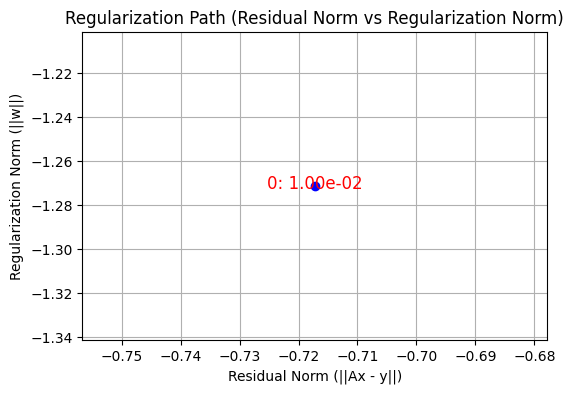

第 0 次迭代的train误差：
S_l_inf= 1.1361253676900795 S_L_2= 0.09833402997707905 S_l_2= 0.33650415254803423
第 0 次迭代的泛化误差：


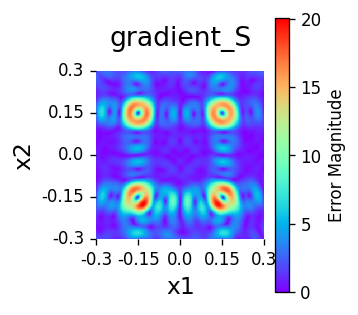

S_l_inf= 1.7567963580292902 S_L_2= 0.11601185361886497 S_l_2= 0.48257963590271535


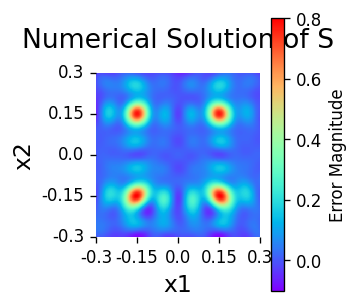

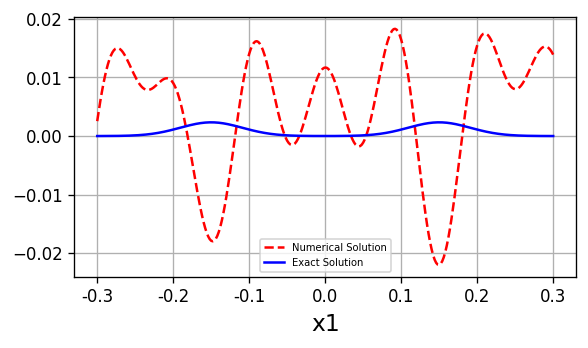

第 0 次自适应网格细分...
S_l_inf= 1.1361253676900795 S_L_2= 0.09833402997707905 S_l_2= 0.33650415254803423
S_l_inf= 1.6335438115694099 S_L_2= 0.11006329027227758 S_l_2= 0.4479844349580715
Generating visualizations...
1. Plotting mesh comparison...


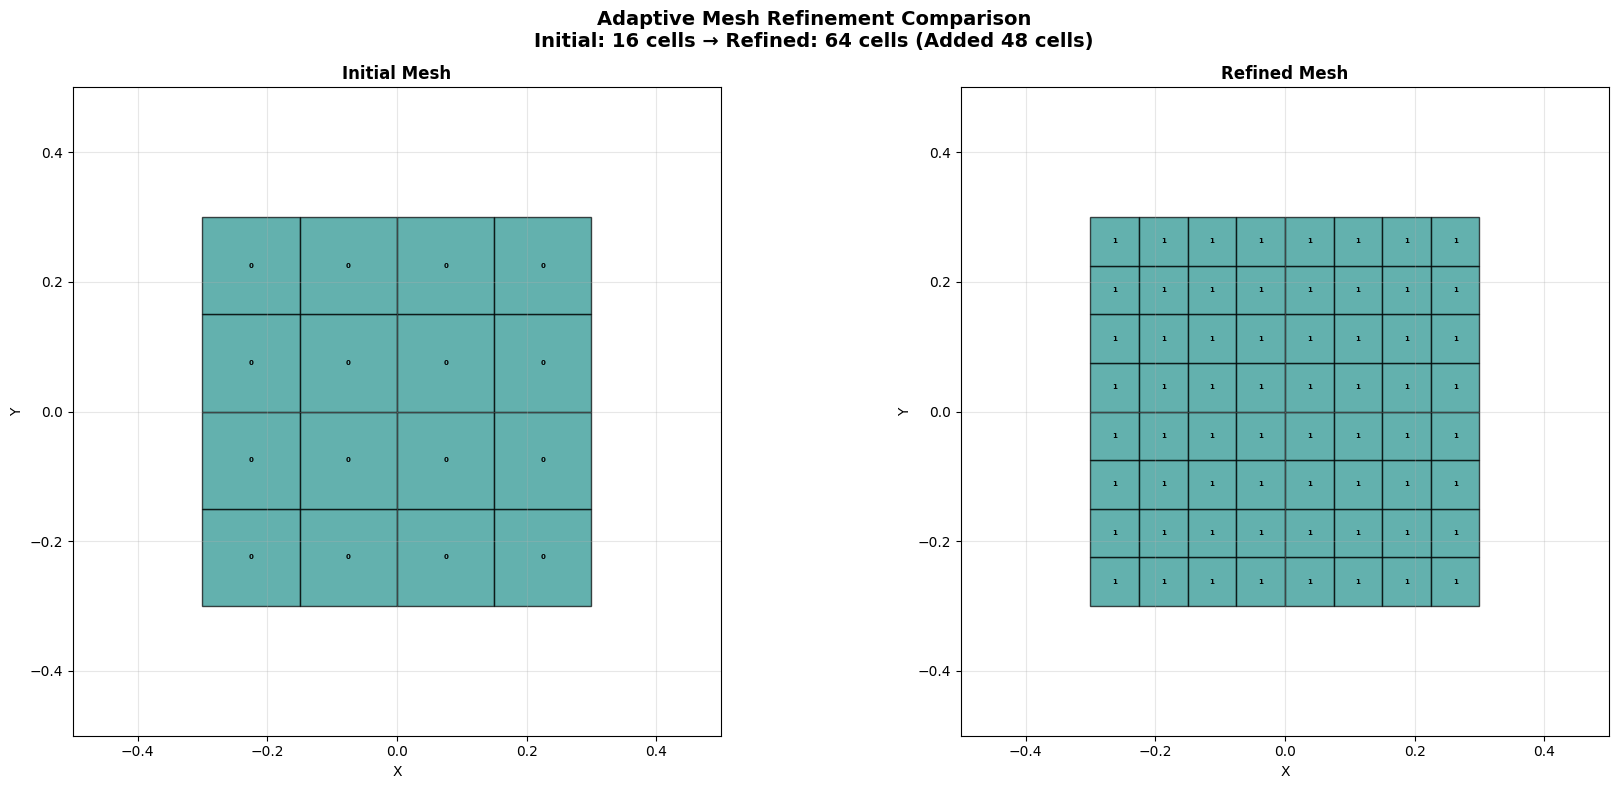

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


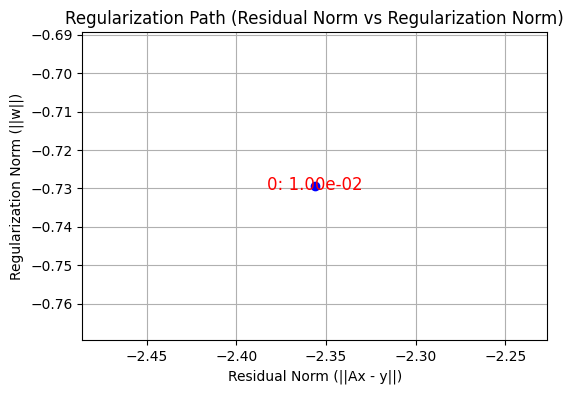

第 1 次迭代的train误差：
S_l_inf= 0.20162742108837658 S_L_2= 0.00900666317782278 S_l_2= 0.03665931578633618
第 1 次迭代的泛化误差：


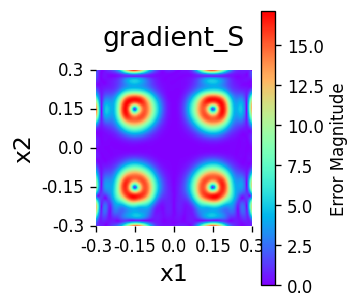

S_l_inf= 0.44685300743082973 S_L_2= 0.013529386062648105 S_l_2= 0.05627878528300918


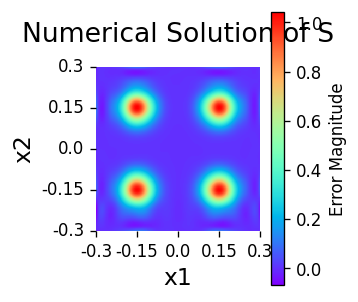

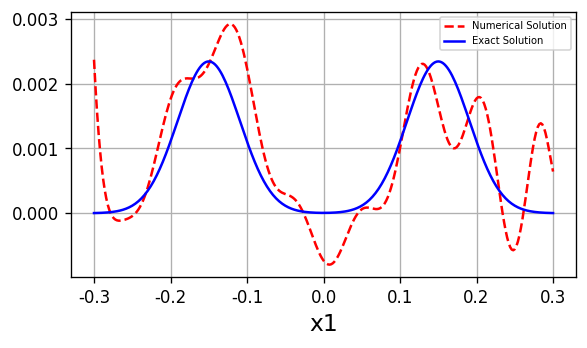

第 1 次自适应网格细分...
S_l_inf= 0.20162742108837658 S_L_2= 0.00900666317782278 S_l_2= 0.03665931578633618
S_l_inf= 0.20242797977622815 S_L_2= 0.012565591425613847 S_l_2= 0.05209584456149916
Generating visualizations...
1. Plotting mesh comparison...


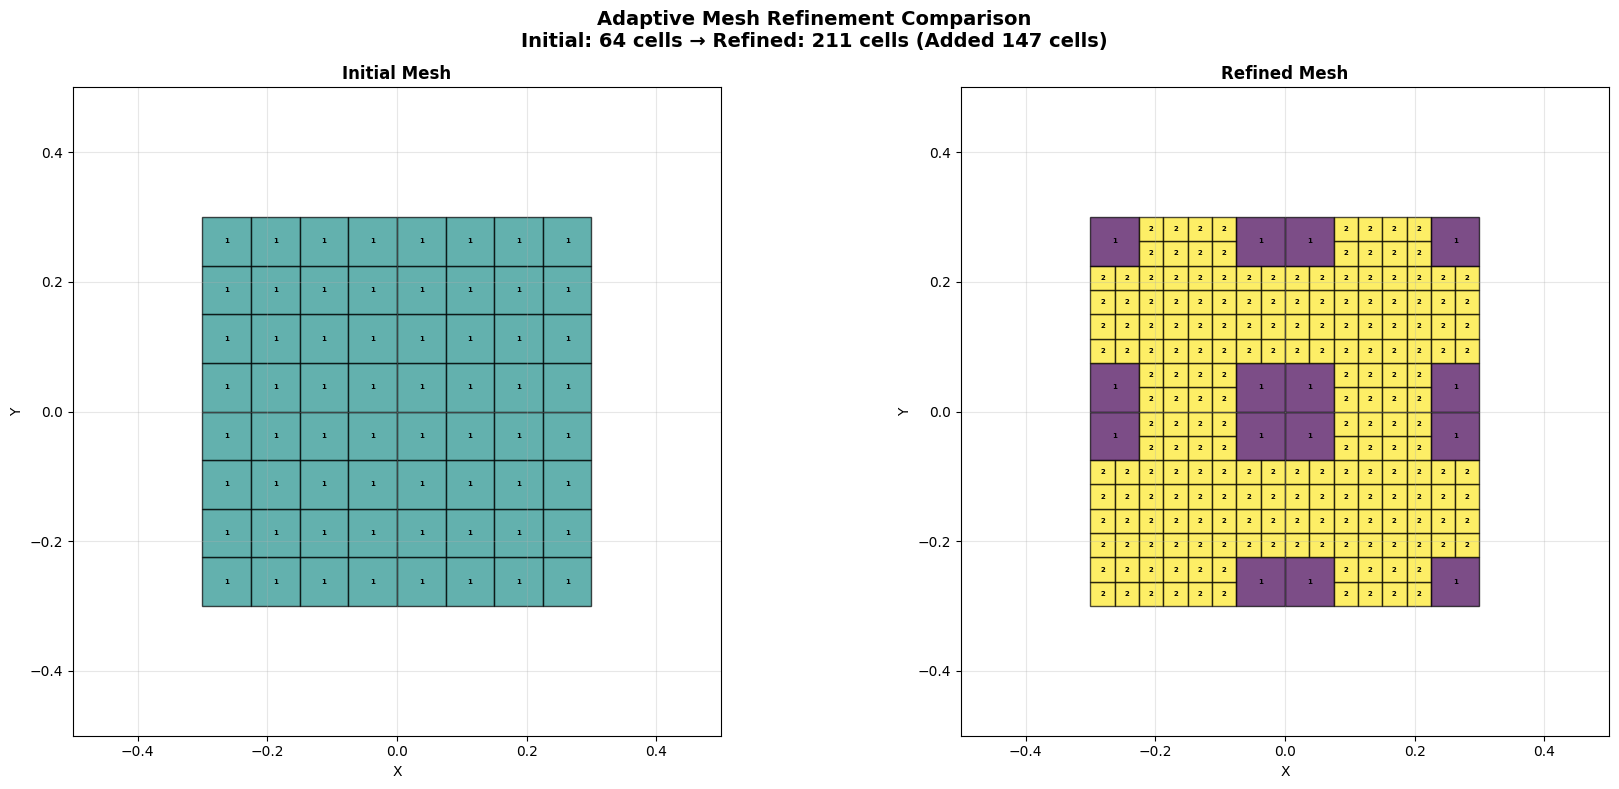

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


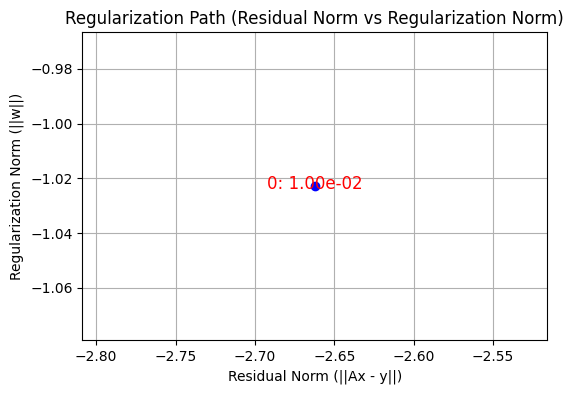

第 2 次迭代的train误差：
S_l_inf= 0.035629368025282174 S_L_2= 0.0015968062260633474 S_l_2= 0.006010472671607085
第 2 次迭代的泛化误差：


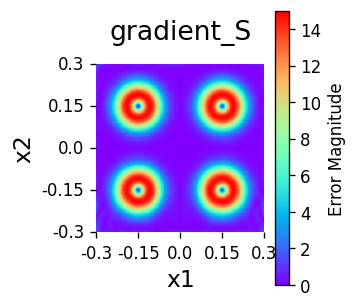

S_l_inf= 0.06405986941073322 S_L_2= 0.0015871741269852747 S_l_2= 0.006602238378425607


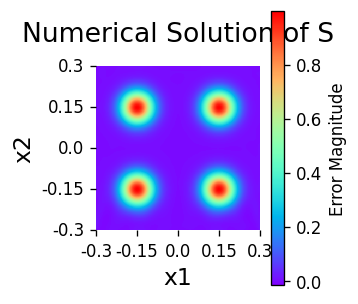

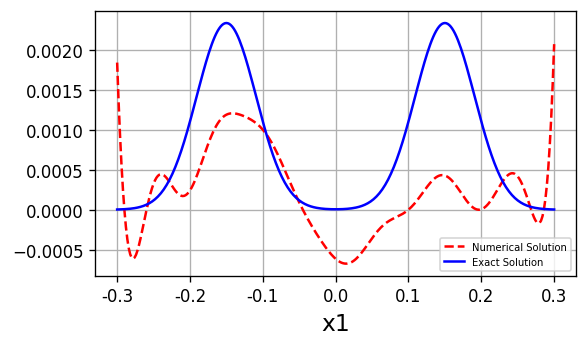

第 2 次自适应网格细分...
S_l_inf= 0.035629368025282174 S_L_2= 0.0015968062260633474 S_l_2= 0.006010472671607085
S_l_inf= 0.04364884022361386 S_L_2= 0.0015893129151931702 S_l_2= 0.005982264244853384
Generating visualizations...
1. Plotting mesh comparison...


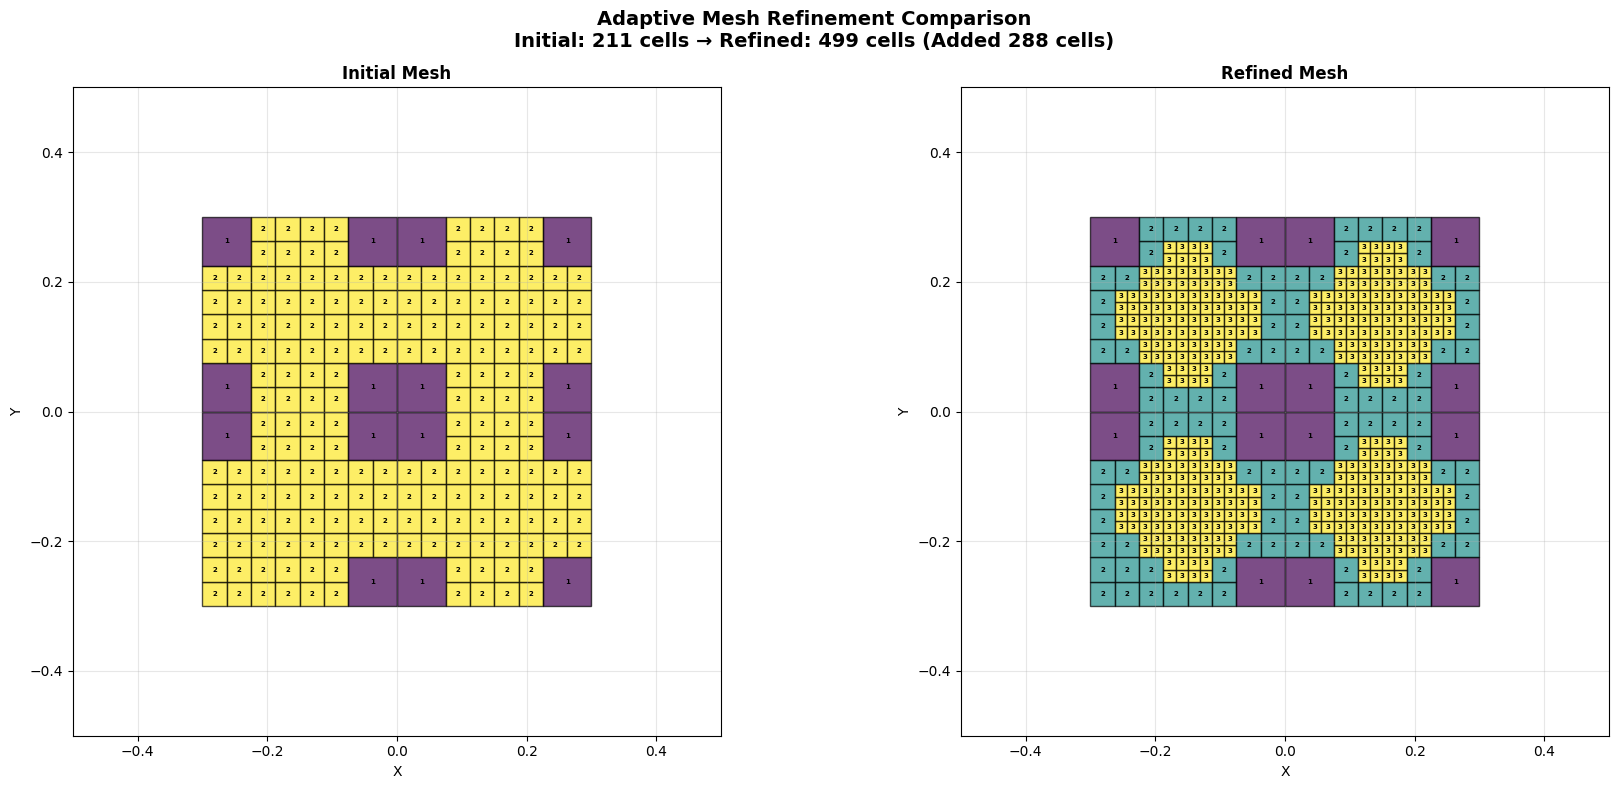

All visualizations completed!


In [4]:
iter_int= 3
Ix,Iy=5,5  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-2,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="sin"
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/1000000000] * 5
refine_threshold_noise=[1/300] * 5
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2=main_fix1.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_1_2,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [6]:
# 保存 models1 模型
torch.save(models0,f"./results/0.5pi/models0_33_3200_{point_number[-1]}_10-4.pth")
np.save("./results/0.5pi/S_num_store",S_num_store)


In [7]:
import pickle # 导入 pickle 模块
output_pickle_file = "./results/0.5pi/cells_store_last.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store[-1], f)